#Extracción de datos Redes Sociales
#TWITTER
##Diana Altamirano

In [1]:
# Importación de librerias
import tweepy
import csv
from tweepy import OAuthHandler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
#Credenciales y autenticaciones
consumer_key = 'TLl1uzvryOvvSzGbahbEkLNuy'
consumer_secret = 'K7Uge1t1qsVxesdReAgDH4Wh3uoPmU4jE2f6hUfk7zjxY69SdP'
access_token = '2357578305-qQR850dj75KPsbKPW23YhvFx8eXI4H5TRtURVDW'
access_secret = 'mA55M04uZXBnMplrbSvbRugyojEuclnzg5Y12D82Fn7I7'
auth = OAuthHandler(consumer_key, consumer_secret)
auth.set_access_token(access_token, access_secret)
api = tweepy.API(auth, wait_on_rate_limit=True)

In [ ]:
#Revisar los tuits que se escribieron en los todos los contactos home
for status in tweepy.Cursor(api.user_timeline).items(10):
    print(status.text)
    

RT @elespectador: Estas son las 12 marcas tecnológicas más valiosas del mundo.
https://t.co/riO93E1UnP https://t.co/OLINiOpKXy
RT @TransitoAmbato: Nuestro Centro de Gestión Semafórica realiza el monitoreo continuo del tránsito en las calles céntricas de la ciudad pa…
#HoyCocinoPorTi#Diego


In [ ]:
# Que elementos se pueden capturar
with open ("AnalisisSuicidio2.csv","w", newline ='\n', encoding = "utf-8") as csvwriter:
    writer = csv.writer(csvwriter,delimiter = "|")
    for status in tweepy.Cursor(api.search, q = "#morir").items(100):
        writer.writerow([status.created_at, status.user.screen_name,status.user.name,status.user.location,status.coordinates,status.place,status.retweet_count,status.favorite_count,status.text.replace("\n","")])

In [ ]:
#Revisar con hashtags
for status in tweepy.Cursor(api.search, q = "Para vivir así lo mejor es estar muerto").items(10):
  #Filtrar por pais
  if ("Quito" or "Ecuador" or "Guayaquil" or "Ambato" in status.user.location):{
        print(status.text)}

Para vivir así lo mejor es estar muerto
@nuriapiera Si estaba depresivo es seguro que van a testimoniar que decía algo como: 
"para vivir así lo mejor es e… https://t.co/HHqbWbcMkk


In [ ]:
# http://docs.tweepy.org/en/v3.5.0/api.html
# https://towardsdatascience.com/how-to-scrape-more-information-from-tweets-on-twitter-44fd540b8a1f
# Que elementos se pueden capturar
with open ("AnalisisFrase1_0612.csv","w", newline ='\n', encoding = "utf-8") as csvwriter:
    writer = csv.writer(csvwriter,delimiter = "|")
    for status in tweepy.Cursor(api.search, q = "la vida no vale la pena").items(100):
        writer.writerow([status.created_at, status.user.screen_name,status.user.name,status.user.location,status.coordinates,status.place,status.retweet_count,status.favorite_count,status.text.replace("\n","")])

Almacenar tweets obtenidos en archivos csv


In [ ]:
# http://docs.tweepy.org/en/v3.5.0/api.html
# https://towardsdatascience.com/how-to-scrape-more-information-from-tweets-on-twitter-44fd540b8a1f
# Obtencion de tweets - almacenados en archivos .csv
with open ("PalabraTristeza.csv","w", newline ='\n', encoding = "utf-8") as csvwriter:
    writer = csv.writer(csvwriter,delimiter = "|")
    for status in tweepy.Cursor(api.search, q = "Tristeza").items(100):
      #Filtrar por pais
      if ('Quito' or 'Ecuador' or 'Guayaquil' or 'Ambato' in status.user.location):{
        writer.writerow([status.created_at, status.user.screen_name,status.user.name,status.user.location,status.coordinates,status.place,status.retweet_count,status.favorite_count,status.text.replace("\n","")])
      }

Procesamiento de los Tweets obtenidos 


In [2]:
tweets_condPara_df = pd.read_csv('AnalisisParasuicida.csv',names=['Fecha','Screen_name','user_name','user_location','coordinates','place','retweet_count','favorite_count','text'],delimiter="|",encoding='latin-1')

In [3]:
tweets_condPara_df.head()


,Fecha,Screen_name,user_name,user_location,coordinates,place,retweet_count,favorite_count,text
0,2020-12-04 01:22:50,kumokyanon,Kumoãü,"MoscÌ¼, Rusia",NaN,NaN,2.0,0.0,"RT @_luisillo19: Bueno, el cÌ_mic de amber lo ..."
1,2020-12-04 01:22:17,_luisillo19,Luisillo(^o^),NaN,NaN,NaN,2.0,18.0,"Bueno, el cÌ_mic de amber lo he estado posponi..."
2,2020-12-03 13:17:08,Elcaaza_,Elcazita ª_ü1K_ü,NaN,NaN,NaN,0.0,0.0,"Gracias por el apoyo en los streams, no se sin..."
3,2020-12-03 02:07:44,withoutacolor,µÝµÄèÁµä,Eiji Akaso's Moles,NaN,NaN,0.0,0.0,Por fin podrÌ© continuar con spl y estoy muuuu...
4,2020-12-02 06:49:09,pizzawinter,_ÒÒ_Ò÷_Ò_Ò_Ò_Ù_ãÝã,I met 5sos,NaN,NaN,0.0,0.0,Ì_ltimamente no he estado bien de salud y ya n...


In [ ]:
tweets_condPara_df.dtypes

Fecha              object
Screen_name        object
user_name          object
user_location      object
coordinates       float64
place              object
retweet_count     float64
favorite_count    float64
text               object
dtype: object

In [ ]:
tweets_condPara_df["user_name"].value_counts().plot(kind='bar')

/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 137 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 157 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 149 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 143 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 137 missing from current font.
  font.set_text(s, 0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 157 missing from current font.
  font.set_text(s, 0, fla

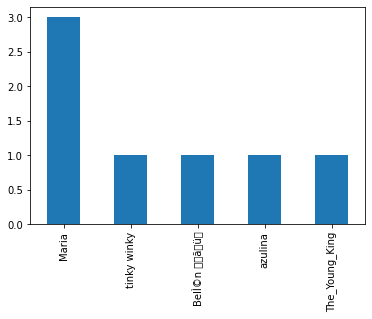

In [ ]:
#Selecionar top de usuarios
tweets_condPara_df["user_name"].value_counts().nlargest(5).plot(kind='bar')

In [ ]:
#Data frame con mas RT de tuits
tweets_condPara_df.groupby(["user_name"])["retweet_count"].sum().nlargest(10).reset_index()

,user_name,retweet_count
0,"Sea Buena Papa, Compre papa",596.0
1,Insuficiente _ÙÎ±,16.0
2,Lilial,16.0
3,N,16.0
4,TÌüddy_Ù¤Ä,16.0
5,_Ò»_Ò¡_Òü_Òá_Ò__Ò»,16.0
6,_ÙÕÉ_ÙÈ_ÙÔÔ,16.0
7,bel con ganas d morir,16.0
8,celeste_ÙÕ,16.0
9,coffee. _Ùâ,16.0


/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 157 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 143 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 141 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 157 missing from current font.
  font.set_text(s, 0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 143 missing from current font.
  font.set_text(s, 0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 141 missing from current font.
  font.set_text(s, 0, flags

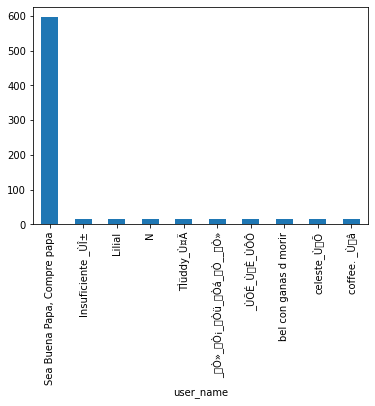

In [ ]:
#Data frame con mas RT de tuits
tweets_condPara_df.groupby(["user_name"])["retweet_count"].sum().nlargest(10).plot(kind='bar')

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
#Extraigo un tuit 
text = tweets_condPara_df.text[15]

In [ ]:
text

'@Camilika03164 \x8bÛ\x9d no, nadie puede ayudarme  . . .se que esto pasara, tranquila! Creo que son peores mis rabietas que\x89Û_ https://t.co/PYOsnO93Rr,,,,,,,,,,,,,,,,,,,'

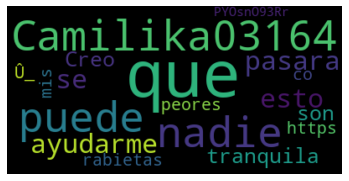

In [ ]:
#genero un word cloud de ese tuit
wordcloud = WordCloud().generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

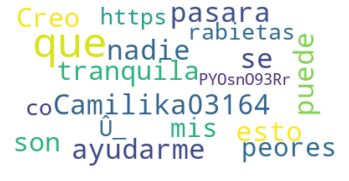

In [ ]:
#Otro modelo de word cloud
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
wordcloud.to_file("Word.png")

In [ ]:
#acumular el texto
text = " ".join(str(review) for review in tweets_condPara_df.text)
print ("Hay {} palabras en la combinación de todos los tuits.".format(len(text)))

Hay 23471 palabras en la combinación de todos los tuits.


In [ ]:
stopwords = set(STOPWORDS)
stopwords.update(["https", "mis", "por", "el", "de","mcdc_mcdc","RT","una","co","es","en","son","se","que","la","lo","u"])

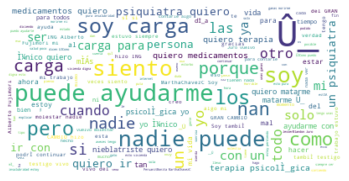

In [ ]:
#https://www.datacamp.com/community/tutorials/wordcloud-python
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
def remove_url(txt):
    return " ".join(re.sub("([^0-9A-Za-z \t])|(\w+:\/\/\S+)", "", txt).split())

In [ ]:
import re

In [ ]:
text=remove_url(text)

In [ ]:
text

'RT luisillo19 Bueno el cmic de amber lo he estado posponiendo por falta de tiempo No s si el fin de semana lo podr continuar pero Bueno el cmic de amber lo he estado posponiendo por falta de tiempo No s si el fin de semana lo podr continuar Gracias por el apoyo en los streams no se sinceramente si podre continuar y por cuanto tiempo ms peor les agrade Por fin podr continuar con spl y estoy muuuuy nerviosa ajdkaks no s si reiniciarla para dar ms tiempo a que acab ltimamente no he estado bien de salud y ya no se si podre continuar ah o debera buscar otro lugar para colaborar Ahora mismo no me duele porque ya habia pasado por esto Fhs se lo haban dejado ya se vea que no lo queran contin No s si podr hacer una retrospectiva de toda la saga considerando lo viejo que es mi PC 15 aos y que no teng Dos de mis cinco hermanas han desactivado ayer sin duda alguna mi vida va de mal en peor No s si podr continuar as EvsMaa21 Cada cap me dejan con ms dudas pero es que si me matan a inuyasha yo no s

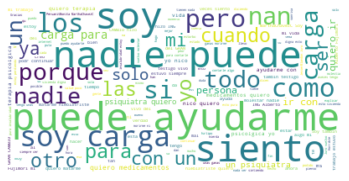

In [ ]:
#https://www.datacamp.com/community/tutorials/wordcloud-python
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
wordcloud.to_file("WordCloudTweets.png")

In [ ]:
from io import StringIO


In [ ]:
tweets_condPara_df.head()

,Fecha,Screen_name,user_name,user_location,coordinates,place,retweet_count,favorite_count,text
0,2020-12-04 01:22:50,kumokyanon,Kumoãü,"MoscÌ¼, Rusia",NaN,NaN,2.0,0.0,"RT @_luisillo19: Bueno, el cÌ_mic de amber lo ..."
1,2020-12-04 01:22:17,_luisillo19,Luisillo(^o^),NaN,NaN,NaN,2.0,18.0,"Bueno, el cÌ_mic de amber lo he estado posponi..."
2,2020-12-03 13:17:08,Elcaaza_,Elcazita ª_ü1K_ü,NaN,NaN,NaN,0.0,0.0,"Gracias por el apoyo en los streams, no se sin..."
3,2020-12-03 02:07:44,withoutacolor,µÝµÄèÁµä,Eiji Akaso's Moles,NaN,NaN,0.0,0.0,Por fin podrÌ© continuar con spl y estoy muuuu...
4,2020-12-02 06:49:09,pizzawinter,_ÒÒ_Ò÷_Ò_Ò_Ò_Ù_ãÝã,I met 5sos,NaN,NaN,0.0,0.0,Ì_ltimamente no he estado bien de salud y ya n...


In [4]:
#se separan solo las columnas necesarias
col = ['Fecha', 'text']

In [5]:
df_Parasuicida = tweets_condPara_df[col]

In [6]:
conducta= "Parasuicida"

In [8]:
#asignar columna con el tipo de conducta
df_Parasuicida = df_Parasuicida.assign(**{'conducta': conducta})


In [ ]:
#borrado de columnas a;adidas por error
df=df.drop(['conducta','columna'], axis=1)

In [9]:
df_Parasuicida.head()

,Fecha,text,conducta
0,2020-12-04 01:22:50,"RT @_luisillo19: Bueno, el cÌ_mic de amber lo ...",Parasuicida
1,2020-12-04 01:22:17,"Bueno, el cÌ_mic de amber lo he estado posponi...",Parasuicida
2,2020-12-03 13:17:08,"Gracias por el apoyo en los streams, no se sin...",Parasuicida
3,2020-12-03 02:07:44,Por fin podrÌ© continuar con spl y estoy muuuu...,Parasuicida
4,2020-12-02 06:49:09,Ì_ltimamente no he estado bien de salud y ya n...,Parasuicida


In [10]:
tweets_condSui_df = pd.read_csv('AnalisisSuicida.csv',names=['Fecha','Screen_name','user_name','user_location','coordinates','place','retweet_count','favorite_count','text'],delimiter="|",encoding='latin-1')

In [ ]:
tweets_condSui_df.head()

,Fecha,Screen_name,user_name,user_location,coordinates,place,retweet_count,favorite_count,text
0,2020-12-07 14:03:45,diamantina__20,Flor de LiZbertad_ö__öÂ_©_«´Ù(antes n...,Nicaragua,NaN,NaN,0.0,0,"@matagalpaunida Vale la pena vivir, porque viv..."
1,2020-12-07 13:42:42,ajlnbless,Anny,Venezuela,NaN,NaN,0.0,0,"Hay que saber cundo decir no, cuando parar; ..."
2,2020-12-07 13:41:59|EndryGonzalez|Endry gonzal...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-12-07 13:33:00,Gabriela2508,Gabbs Almeida,En M©xico,NaN,NaN,0.0,0,Mi mam siempre me dice: S_lo se vale ten...
4,2020-12-07 13:28:14,Tinojaramillo,Martin Jaramillo L,"Bogot, D.C., Colombia",NaN,NaN,2.0,0,RT @golantrevize199: Los epidemi_logos tienen...


In [ ]:
col = ['Fecha', 'text']

In [11]:
df_Suicida = tweets_condSui_df[col]

In [12]:
df_Suicida.head()

,Fecha,text
0,2020-12-07 14:03:45,"@matagalpaunida Vale la pena vivir, porque viv..."
1,2020-12-07 13:42:42,"Hay que saber cundo decir no, cuando parar; ..."
2,2020-12-07 13:41:59|EndryGonzalez|Endry gonzal...,NaN
3,2020-12-07 13:33:00,Mi mam siempre me dice: S_lo se vale ten...
4,2020-12-07 13:28:14,RT @golantrevize199: Los epidemi_logos tienen...


In [13]:
conducta= "Suicida"
#asignar columna con el tipo de conducta
df_Suicida = df_Suicida.assign(**{'conducta': conducta})

In [14]:
df_Suicida.head()

,Fecha,text,conducta
0,2020-12-07 14:03:45,"@matagalpaunida Vale la pena vivir, porque viv...",Suicida
1,2020-12-07 13:42:42,"Hay que saber cundo decir no, cuando parar; ...",Suicida
2,2020-12-07 13:41:59|EndryGonzalez|Endry gonzal...,NaN,Suicida
3,2020-12-07 13:33:00,Mi mam siempre me dice: S_lo se vale ten...,Suicida
4,2020-12-07 13:28:14,RT @golantrevize199: Los epidemi_logos tienen...,Suicida


In [ ]:
#union de dataframes
df_conductas = pd.concat([df_Suicida, df_Parasuicida])

In [ ]:
df_conductas.tail()

,Fecha,text,conducta
180,2020-12-05 08:25:46,Siempre me siento que soy una carga para todos...,Parasuicida
181,"2020-12-05 05:46:13|_whxtsername_|ªÁ||||5|0|""...",NaN,Parasuicida
182,2020-12-05 05:35:23,RT @hera106: #DiaInternacionalDeLaDiscapacidad...,Parasuicida
183,2020-12-05 05:33:48,#DiaInternacionalDeLaDiscapacidad #SanMiguelde...,Parasuicida
184,2020-12-05 05:20:18|nieblatriste|coffee. _Ùâ|...,NaN,Parasuicida


In [15]:
tweets_condNoDet_df = pd.read_csv('AnalisisNoDeterminada.csv',names=['Fecha','Screen_name','user_name','user_location','coordinates','place','retweet_count','favorite_count','text'],delimiter="|",encoding='latin-1')

In [ ]:
tweets_condNoDet_df.head()

,Fecha,Screen_name,user_name,user_location,coordinates,place,retweet_count,favorite_count,text
0,2020-12-07 14:25:57,GotfrydLau,Lau Gotfryd_ÙÕ_,Ciudad AutÌ_noma de Buenos Aire,NaN,NaN,0,0.0,Sobre el tema de la impuntualidad solo dire qu...
1,2020-12-07 14:25:29,AgostiniJaz,Jaz Agostini,NaN,NaN,NaN,633,0.0,RT @iamweronika: TenÌ_a una amiga con una comb...
2,2020-12-07 14:25:03,AnaMaraCrespo,Ana MarÌ_a Crespo,Madrid,NaN,NaN,77,0.0,RT @gorka_orive: Sigue empeorando la salud men...
3,2020-12-07 14:25:02,luciferhxtxkx,diabla,NaN,NaN,NaN,0,0.0,Quiero que sea 18 ya para ir a ver a Neisser y...
4,2020-12-07 14:24:58,desdeorigenes,Desde los OrÌ_genes,NaN,NaN,NaN,0,0.0,"Ruth, en su rol como lawentuchefe explica que,..."


In [ ]:
#se separan solo las columnas necesarias
col = ['Fecha', 'text']

In [16]:
df_NoDet = tweets_condNoDet_df[col]

In [ ]:
df_NoDet.head()

,Fecha,text
0,2020-12-07 14:25:57,Sobre el tema de la impuntualidad solo dire qu...
1,2020-12-07 14:25:29,RT @iamweronika: TenÌ_a una amiga con una comb...
2,2020-12-07 14:25:03,RT @gorka_orive: Sigue empeorando la salud men...
3,2020-12-07 14:25:02,Quiero que sea 18 ya para ir a ver a Neisser y...
4,2020-12-07 14:24:58,"Ruth, en su rol como lawentuchefe explica que,..."


In [17]:
conducta= "NoDeterminada"
#asignar comuna con el tipo de conducta
df_NoDet = df_NoDet.assign(**{'conducta': conducta})

In [18]:
df_NoDet.head()

,Fecha,text,conducta
0,2020-12-07 14:25:57,Sobre el tema de la impuntualidad solo dire qu...,NoDeterminada
1,2020-12-07 14:25:29,RT @iamweronika: TenÌ_a una amiga con una comb...,NoDeterminada
2,2020-12-07 14:25:03,RT @gorka_orive: Sigue empeorando la salud men...,NoDeterminada
3,2020-12-07 14:25:02,Quiero que sea 18 ya para ir a ver a Neisser y...,NoDeterminada
4,2020-12-07 14:24:58,"Ruth, en su rol como lawentuchefe explica que,...",NoDeterminada


In [19]:
#union de dataframes
df_conductas = pd.concat([df_Suicida, df_Parasuicida,df_NoDet])

In [20]:
#eliminando valores nan
df_conductas.dropna( inplace=True )

In [21]:
df_conductas.head()

,Fecha,text,conducta
0,2020-12-07 14:03:45,"@matagalpaunida Vale la pena vivir, porque viv...",Suicida
1,2020-12-07 13:42:42,"Hay que saber cundo decir no, cuando parar; ...",Suicida
3,2020-12-07 13:33:00,Mi mam siempre me dice: S_lo se vale ten...,Suicida
4,2020-12-07 13:28:14,RT @golantrevize199: Los epidemi_logos tienen...,Suicida
5,2020-12-07 13:26:02,"@Umbraixen Lon, no vale la pena perder el tiem...",Suicida


In [ ]:
df_conductas.tail()

,Fecha,text,conducta
596,2020-12-07 14:27:09,RT @FR4KT4L: @oatila NÌ£o tÌÁ chato.TÌÁ decepc...,NoDeterminada
597,2020-12-07 14:27:07,RT @CristoBustos: Nueva masacre en Santander d...,NoDeterminada
598,2020-12-07 14:27:03,"@opalinhaah que b.o? _Ù_Á,,,,,,,,,,,,,,,,,,,,,,",NoDeterminada
599,2020-12-07 14:27:02,åÁQue tristeza! MÌ©xico cada dÌ_a se hunde mÌÁ...,NoDeterminada
600,2020-12-07 14:27:00,Estudar as polÌ_ticas de saÌ¼de mental enquant...,NoDeterminada


In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [ ]:
#acumular el texto
text = " ".join(str(review) for review in df_conductas.text)
print ("Hay {} palabras en la combinación de todos los tuits.".format(len(text)))

Hay 166055 palabras en la combinación de todos los tuits.


In [ ]:

#quitar palabras no deseadas
stopwords = set(STOPWORDS)
stopwords.update(["https", "mis", "por", "el", "de","mcdc_mcdc","RT","una","co","es","en","son","se","que","la","lo","u","rt","no","un","de","los","pero"])

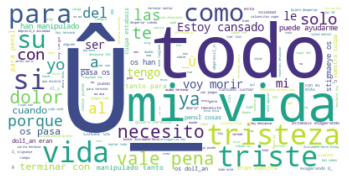

In [ ]:
#nube de palabras de todo el conjunto de datos
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
#convertir dataframe a csv y expotar
datos=df_conductas.to_csv('df_conductas2.csv', header=True)


In [ ]:
import matplotlib.pyplot as plt

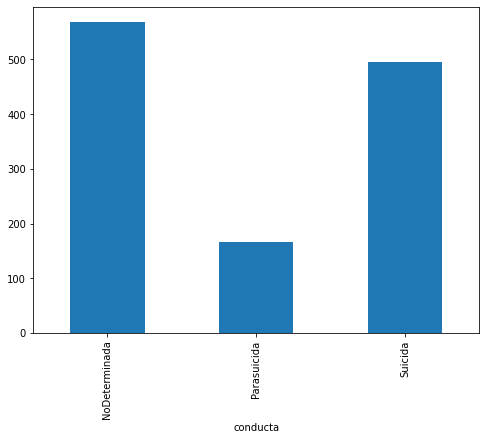

In [ ]:

fig = plt.figure(figsize=(8,6))
df_conductas.groupby('conducta').text.count().plot.bar(ylim=0)
plt.show()

IMPLEMENTACION DE LOS MODELOS

In [22]:
from sklearn.feature_selection import chi2
import numpy as np

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
import pandas as pd


In [24]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report

In [25]:
X_train, X_test, y_train, y_test = train_test_split(df_conductas['text'], df_conductas['conducta'], test_size=0.1, random_state=12)

In [26]:
#validacion cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True)

In [27]:
#trasnformacion de texto a vectores
tfidf_vectorizer = TfidfVectorizer(smooth_idf=True, norm='l2', sublinear_tf=True)

REGRESION LOGISTICA

Clasificador con parametros por defecto 

In [28]:
#Clasificador Regresion Logistica
lgr_model = LogisticRegression(C=25, solver='saga', max_iter=2000)

In [29]:
#concatenar los pasos anteriores
lgr_pipeline = Pipeline([('tfidf', tfidf_vectorizer),('clf', lgr_model)])

In [30]:
lgr_pipeline.fit(X_train, y_train)

Pipeline(memory=None,
         steps=[('tfidf',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=1, ngram_range=(1, 1), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words=None, strip_accents=None,
                                 sublinear_tf=True,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=None, use_idf=True,
                                 vocabulary=None)),
                ('clf',
                 LogisticRegression(C=25, class_weight=None, dual=False,
                                    fit_intercept=True, intercept_scaling=1

In [31]:
len(lgr_pipeline[0].get_feature_names())

4621

evaluacion de accuracy


In [32]:
preds_train2 = lgr_pipeline.predict(X_train)
preds_test2 = lgr_pipeline.predict(X_test)
print('accuracy in train:', accuracy_score(preds_train2, y_train))
print('accuracy in test:', accuracy_score(preds_test2, y_test))

accuracy in train: 1.0
accuracy in test: 0.975609756097561


Clasificador con parametros modificados

In [ ]:
lr2 = LogisticRegression(fit_intercept=True, penalty='l2', tol=1e-5, C=0.8, solver='lbfgs', max_iter=75,
                       warm_start=True)

In [ ]:
lr2.fit(X_train, y_train)
preds_train2 = lr2.predict(X_train)
preds_test2 = lr2.predict(X_test)
print('accuracy in train:', accuracy_score(preds_train2, y_train))
print('accuracy in test:', accuracy_score(preds_test2, y_test))

ValueError: ignored

**Validacion del modelo**


In [33]:
scores = cross_val_score(lgr_pipeline, X_train, y_train, cv=cv)
sc_mean = scores.mean()
sc_dev = scores.std()*2
print(f'''Accuracy per fold: {scores}
Mean accuracy: {round(scores.mean(),3)}
Std. deviation: +- {round(scores.std()*2,3)}''')

Accuracy per fold: [0.98198198 0.97297297 1.         0.97297297 0.95495495 0.93693694
 0.94545455 0.95454545 0.98181818 0.92727273]
Mean accuracy: 0.963
Std. deviation: +- 0.043


In [35]:
pip install eli5

     |████████████████████████████████| 112kB 5.1MB/s 


In [36]:
import eli5

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.feature_selection.base module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.feature_selection. Anything that cannot be imported from sklearn.feature_selection is now part of the private API.
  warnings.warn(message, FutureWarning)


In [ ]:
# con 20 palabras más importante de cada clase
eli5.show_weights(lgr_pipeline, vec=lgr_pipeline[0], top=20, feature_filter=lambda x: x != '<BIAS>') 

               precision    recall  f1-score   support

NoDeterminada       0.98      0.89      0.93        61
  Parasuicida       0.94      0.94      0.94        18
      Suicida       0.86      0.98      0.91        44

     accuracy                           0.93       123
    macro avg       0.93      0.94      0.93       123
 weighted avg       0.93      0.93      0.93       123



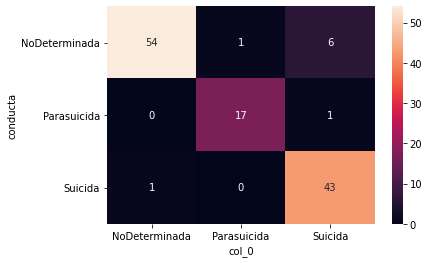

In [ ]:
#metricas de evaluacion y matriz de confusion
y_pred = lgr_pipeline.predict(X_test)
confs_matrix = pd.crosstab(y_test, y_pred)
sns.heatmap(confs_matrix, annot=True, cbar=True)
y_test = list(y_test)
X_test = list(X_test)
mistakes = [X_test[i] for i in range(len(y_pred)) if y_test[i] != y_pred[i]]
print(classification_report(y_test, y_pred))

In [ ]:
#Analisis de errores - palabras que confunden al algoritmo
print(f'{len(mistakes)} mistakes from {len(y_test)} validation samples:')
for i,f in enumerate(mistakes):
    print(f"X {f} -> {y_test[i]}")

9 mistakes from 123 validation samples:
X Antes me frustraba la idea de que nadie entendiera lo que es vivir con un trastorno, ansiedad y depresiÌ_n, pero hoyÛ_ https://t.co/LsIWpQxOEB,,,,,,,,,,,,,,,,,,,,, -> NoDeterminada
X @farriancito @yakuperezg todo una joya, un perdedor de nacimiento, que quiere ser lo que no puede, que triste por Ì©l https://t.co/K3BhPyqfU8,,,,,,,,,,,,,,,,,,,, -> NoDeterminada
X @jostipi @SBSPERU ...Y todo en las narices de los periodistas y crÌ_ticos que siempre se llenan la boca que son losÛ_ https://t.co/iUQ8VKWipz,,,, -> Suicida
X Dejadme morir joder, no soporto este dolor y estÌÁ angustia mÌÁs, estoy cansada y este mundo no es para mi, asumidloÛ_ https://t.co/M9hbcK5JoQ,,,,,,,,,,,,,,,,,,,, -> Parasuicida
X Me siento muy soft. Ì_ltimamente estuve teniendo pensamientos de mierda en cuanto a mi propia presencia, me sentÌ_a uÛ_ https://t.co/80YF1WzmWR,,,,,,,,,,,,,,,, -> Suicida
X Vale, llevo aÌ±os anteponiendo mi salud mental a mis estudios y lo Ì¼nico que 

In [ ]:
#analisis del primer error
eli5.show_prediction(lgr_pipeline[1], doc=mistakes[0], vec=lgr_pipeline[0])

NAYVE BAYES

Vectorizacion de terminos

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=5, norm='l2', encoding='latin-1', ngram_range=(1, 2), stop_words='english')

In [39]:
features = tfidf.fit_transform(df_conductas.text).toarray()
labels = df_conductas.conducta

In [40]:
features.shape

(1229, 1014)

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

In [42]:
X_train, X_test, y_train, y_test = train_test_split(df_conductas['text'], df_conductas['conducta'],random_state = 0)

In [43]:
print('Number of rows in the total set: {}'.format(df_conductas.shape[0]))
print('Number of rows in the training set: {}'.format(X_train.shape[0]))
print('Number of rows in the test set: {}'.format(X_test.shape[0]))

Number of rows in the total set: 1229
Number of rows in the training set: 921
Number of rows in the test set: 308


In [44]:
count_vect = CountVectorizer()

In [45]:
X_train_counts = count_vect.fit_transform(X_train)


In [46]:
tfidf_transformer = TfidfTransformer()

In [47]:
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

In [48]:
X_train_tfidf

<921x4066 sparse matrix of type '<class 'numpy.float64'>'
	with 15443 stored elements in Compressed Sparse Row format>

In [ ]:
#clf = MultinomialNB().fit(X_train_tfidf, y_train)

In [49]:
clf = MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True).fit(X_train_tfidf, y_train)

In [50]:
testing_data = count_vect.transform(X_test)

In [51]:
predictions=clf.predict(testing_data)

In [52]:
print('Accuracy score: ', format(accuracy_score(y_test, predictions)))

Accuracy score:  0.8603896103896104


In [53]:
print('Precision score: ', format(precision_score(y_test, predictions)))

NameError: ignored

In [ ]:
print('F1 score: ', format(f1_score(y_test, predictions)))

ValueError: ignored

PREDICCIONES

Frase 10 de Tabla Tabla 4. Frases/palabras por clase.

In [54]:
print(clf.predict(count_vect.transform(["Podría morir ahora y nadie se daría cuenta"])))


['Suicida']


In [61]:
print(clf.predict(count_vect.transform(["dolor"]))) 


['NoDeterminada']


METRICAS

In [ ]:
# Instantiate the CountVectorizer method
count_vector = CountVectorizer()

In [ ]:
# Fit the training data and then return the matrix
training_data = X_train_counts

In [ ]:
# Transform testing data and return the matrix. Note we are not fitting the testing data into the CountVectorizer()
testing_data = count_vect.transform(X_test)

In [ ]:
naive_bayes = MultinomialNB().fit(X_train_tfidf, y_train)

In [ ]:
predictions=naive_bayes.predict(testing_data)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, clf)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
print('Accuracy score: ', format(accuracy_score(y_test, predictions)))
print('Precision score: ', format(precision_score(y_test, predictions)))
 

In [ ]:
print('Recall score: ', format(recall_score(y_test, predictions)))
print('F1 score: ', format(f1_score(y_test, predictions)))

ValueError: ignored

EVALUACION COMPARATIVA

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

In [ ]:
from sklearn.feature_selection import chi2
import numpy as np
N = 2

In [ ]:
models = [MultinomialNB(),]

In [ ]:
CV=10

In [ ]:
cv_df = pd.DataFrame(index=range(CV * len(models)))

In [ ]:
entries = []

In [ ]:
for model in models:
  model_name = model.__class__.__name__


In [ ]:
accuracies = cross_val_score(model, features, labels, scoring='accuracy', cv=CV)

In [ ]:
for fold_idx, accuracy in enumerate(accuracies):
  entries.append((model_name, fold_idx, accuracy))

In [ ]:
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])

In [ ]:
import seaborn as sns

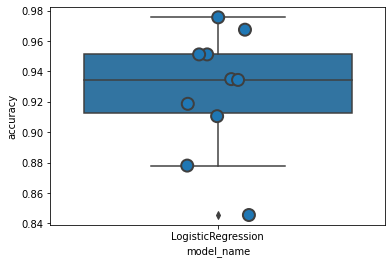

In [ ]:
sns.boxplot(x='model_name', y='accuracy', data=cv_df)
sns.stripplot(x='model_name', y='accuracy', data=cv_df,
size=12, jitter=True, edgecolor="gray", linewidth=2)
plt.show()

In [ ]:
cv_df.groupby('model_name').accuracy.mean()

model_name
MultinomialNB    0.908863
Name: accuracy, dtype: float64

otras metricas

In [ ]:
recall_value = cross_val_score(model, features, labels, scoring='recall', cv=CV)

ValueError: ignored

In [ ]:
cv_df.groupby('model_name').accuracy.mean()